# Product Cluster Analysis

## Project Overview

This project performs product clustering analysis using historical sales data to identify groups of products with similar sales behavior.

The analysis focuses on retail sales, retail transfers, warehouse sales, sales variability, and product activity to segment products into meaningful groups.

## Objectives

- Identify products with similar sales patterns.
- Segment products using an unsupervised machine learning approach.
- Evaluate the quality of the resulting clusters.
- Understand the characteristics of each product cluster.
- Generate insights that can support inventory management and product planning.

## Methodology

1. Data Loading and Understanding
2. Data Quality Analysis
3. Product-Level Feature Engineering
4. Feature Transformation and Preprocessing
5. K-Means Clustering
6. Cluster Evaluation
7. PCA-Based Visualization
8. Cluster Profiling
9. Business Insights

## Final Model

**Algorithm:** K-Means Clustering  
**Number of Clusters:** 2

In [4]:
# ============================================
# PRODUCT & SALES PATTERN CLUSTERING
# Step 1: Load and Inspect Dataset
# ============================================

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\Users\ansar\OneDrive\Downloads\Warehouse_and_Retail_Sales.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (307645, 9)

Column Names:
['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

Data Types:
YEAR                  int64
MONTH                 int64
SUPPLIER             object
ITEM CODE            object
ITEM DESCRIPTION     object
ITEM TYPE            object
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
dtype: object

First 5 Rows:


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0



Missing Values:
YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

Duplicate Rows: 0


In [5]:
# ============================================
# Step 2: Data Quality Analysis
# ============================================

# Missing values
print("Missing Values:")
print(df.isnull().sum())

# Missing value percentage
print("\nMissing Value Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Unique values in categorical columns
print("\nUnique Values:")
print("Suppliers:", df['SUPPLIER'].nunique())
print("Item Codes:", df['ITEM CODE'].nunique())
print("Item Descriptions:", df['ITEM DESCRIPTION'].nunique())
print("Item Types:", df['ITEM TYPE'].nunique())

# Date range
print("\nYear Range:")
print(df['YEAR'].min(), "to", df['YEAR'].max())

print("\nMonths Available:")
print(sorted(df['MONTH'].unique()))

Missing Values:
YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

Missing Value Percentage:
YEAR                0.00
MONTH               0.00
SUPPLIER            0.05
ITEM CODE           0.00
ITEM DESCRIPTION    0.00
ITEM TYPE           0.00
RETAIL SALES        0.00
RETAIL TRANSFERS    0.00
WAREHOUSE SALES     0.00
dtype: float64

Duplicate Rows:
0

Unique Values:
Suppliers: 396
Item Codes: 34056
Item Descriptions: 34822
Item Types: 8

Year Range:
2017 to 2020

Months Available:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [6]:
# ============================================
# Step 3: Numerical Sales Analysis
# ============================================

sales_columns = [
    'RETAIL SALES',
    'RETAIL TRANSFERS',
    'WAREHOUSE SALES'
]

# Descriptive statistics
print("Sales Variable Statistics:")
display(df[sales_columns].describe().T)

# Check negative values
print("\nNegative Values:")
for column in sales_columns:
    negative_count = (df[column] < 0).sum()
    print(f"{column}: {negative_count}")

# Check zero values
print("\nZero Values:")
for column in sales_columns:
    zero_count = (df[column] == 0).sum()
    print(f"{column}: {zero_count}")

# Check missing values
print("\nMissing Values:")
for column in sales_columns:
    missing_count = df[column].isnull().sum()
    print(f"{column}: {missing_count}")

Sales Variable Statistics:


,count,mean,std,min,25%,50%,75%,max
RETAIL SALES,307642.0,7.024071,30.986238,-6.49,0.0,0.32,3.2675,2739.00
RETAIL TRANSFERS,307645.0,6.936465,30.237195,-38.49,0.0,0.00,3.0000,1990.83
WAREHOUSE SALES,307645.0,25.294597,249.916798,-7800.00,0.0,1.00,5.0000,18317.00



Negative Values:
RETAIL SALES: 113
RETAIL TRANSFERS: 1016
WAREHOUSE SALES: 716

Zero Values:
RETAIL SALES: 121702
RETAIL TRANSFERS: 188464
WAREHOUSE SALES: 96950

Missing Values:
RETAIL SALES: 3
RETAIL TRANSFERS: 0
WAREHOUSE SALES: 0


In [7]:
# ============================================
# Step 4: Create Product-Level Feature Dataset
# ============================================

# Make a copy of the original data
product_df = df.copy()

# --------------------------------------------
# Handle missing values
# --------------------------------------------

product_df['RETAIL SALES'] = product_df['RETAIL SALES'].fillna(
    product_df['RETAIL SALES'].median()
)

product_df['SUPPLIER'] = product_df['SUPPLIER'].fillna(
    product_df['SUPPLIER'].mode()[0]
)

product_df['ITEM TYPE'] = product_df['ITEM TYPE'].fillna(
    product_df['ITEM TYPE'].mode()[0]
)

# --------------------------------------------
# Create total sales across all channels
# --------------------------------------------

product_df['TOTAL SALES'] = (
    product_df['RETAIL SALES']
    + product_df['RETAIL TRANSFERS']
    + product_df['WAREHOUSE SALES']
)

# --------------------------------------------
# Aggregate transaction/monthly records
# into one row per ITEM CODE
# --------------------------------------------

product_features = product_df.groupby('ITEM CODE').agg(
    TOTAL_RETAIL_SALES=('RETAIL SALES', 'sum'),
    TOTAL_RETAIL_TRANSFERS=('RETAIL TRANSFERS', 'sum'),
    TOTAL_WAREHOUSE_SALES=('WAREHOUSE SALES', 'sum'),
    
    AVG_RETAIL_SALES=('RETAIL SALES', 'mean'),
    AVG_RETAIL_TRANSFERS=('RETAIL TRANSFERS', 'mean'),
    AVG_WAREHOUSE_SALES=('WAREHOUSE SALES', 'mean'),
    
    STD_RETAIL_SALES=('RETAIL SALES', 'std'),
    STD_RETAIL_TRANSFERS=('RETAIL TRANSFERS', 'std'),
    STD_WAREHOUSE_SALES=('WAREHOUSE SALES', 'std'),
    
    TOTAL_SALES=('TOTAL SALES', 'sum'),
    
    ACTIVE_MONTHS=('MONTH', 'count'),
    
    SUPPLIER=('SUPPLIER', lambda x: x.mode()[0]),
    ITEM_TYPE=('ITEM TYPE', lambda x: x.mode()[0])
).reset_index()

# --------------------------------------------
# Replace standard deviation NaN values
# for products with only one observation
# --------------------------------------------

std_columns = [
    'STD_RETAIL_SALES',
    'STD_RETAIL_TRANSFERS',
    'STD_WAREHOUSE_SALES'
]

product_features[std_columns] = product_features[std_columns].fillna(0)

# --------------------------------------------
# Display results
# --------------------------------------------

print("Original Dataset Shape:", df.shape)

print("Product-Level Dataset Shape:", product_features.shape)

print("\nNumber of Unique Products:",
      product_features['ITEM CODE'].nunique())

print("\nProduct-Level Dataset Preview:")
display(product_features.head())

print("\nProduct-Level Dataset Information:")
print(product_features.info())

Original Dataset Shape: (307645, 9)
Product-Level Dataset Shape: (34056, 14)

Number of Unique Products: 34056

Product-Level Dataset Preview:


,ITEM CODE,TOTAL_RETAIL_SALES,TOTAL_RETAIL_TRANSFERS,TOTAL_WAREHOUSE_SALES,AVG_RETAIL_SALES,AVG_RETAIL_TRANSFERS,AVG_WAREHOUSE_SALES,STD_RETAIL_SALES,STD_RETAIL_TRANSFERS,STD_WAREHOUSE_SALES,TOTAL_SALES,ACTIVE_MONTHS,SUPPLIER,ITEM_TYPE
0,100002,0.17,0.0,0.0,0.170000,0.0,0.000000,0.000000,0.0,0.000000,0.17,1,RELIABLE CHURCHILL LLLP,LIQUOR
1,100007,0.00,0.0,4.0,0.000000,0.0,1.000000,0.000000,0.0,0.000000,4.00,4,CONSTANTINE WINES INC,WINE
2,100008,0.00,0.0,3.0,0.000000,0.0,1.000000,0.000000,0.0,1.000000,3.00,3,CONSTANTINE WINES INC,WINE
3,100009,1.72,0.0,18.0,0.132308,0.0,1.384615,0.235908,0.0,2.364264,19.72,13,REPUBLIC NATIONAL DISTRIBUTING CO,WINE
4,100011,0.00,0.0,3.0,0.000000,0.0,1.000000,0.000000,0.0,0.000000,3.00,3,INTERBALT PRODUCTS CORP,WINE



Product-Level Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34056 entries, 0 to 34055
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ITEM CODE               34056 non-null  object 
 1   TOTAL_RETAIL_SALES      34056 non-null  float64
 2   TOTAL_RETAIL_TRANSFERS  34056 non-null  float64
 3   TOTAL_WAREHOUSE_SALES   34056 non-null  float64
 4   AVG_RETAIL_SALES        34056 non-null  float64
 5   AVG_RETAIL_TRANSFERS    34056 non-null  float64
 6   AVG_WAREHOUSE_SALES     34056 non-null  float64
 7   STD_RETAIL_SALES        34056 non-null  float64
 8   STD_RETAIL_TRANSFERS    34056 non-null  float64
 9   STD_WAREHOUSE_SALES     34056 non-null  float64
 10  TOTAL_SALES             34056 non-null  float64
 11  ACTIVE_MONTHS           34056 non-null  int64  
 12  SUPPLIER                34056 non-null  object 
 13  ITEM_TYPE               34056 non-null  object 
dtypes:

In [8]:
# ============================================
# Step 5: Product-Level Feature Analysis
# ============================================

# Numerical features
numerical_features = [
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'AVG_RETAIL_SALES',
    'AVG_RETAIL_TRANSFERS',
    'AVG_WAREHOUSE_SALES',
    'STD_RETAIL_SALES',
    'STD_RETAIL_TRANSFERS',
    'STD_WAREHOUSE_SALES',
    'TOTAL_SALES',
    'ACTIVE_MONTHS'
]

# Descriptive statistics
print("Product-Level Feature Statistics:")
display(
    product_features[numerical_features]
    .describe()
    .T
)

# Check for negative values
print("\nNegative Values:")
for column in numerical_features:
    count = (product_features[column] < 0).sum()
    print(f"{column}: {count}")

# Check for zero values
print("\nZero Values:")
for column in numerical_features:
    count = (product_features[column] == 0).sum()
    print(f"{column}: {count}")

# Check for missing values
print("\nMissing Values:")
print(product_features[numerical_features].isnull().sum())

Product-Level Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
TOTAL_RETAIL_SALES,34056.0,63.451384,416.266654,-0.250000,0.000000,0.00,6.470000,27580.500000
TOTAL_RETAIL_TRANSFERS,34056.0,62.660578,409.857936,-8.880000,0.000000,0.00,4.000000,27889.330000
TOTAL_WAREHOUSE_SALES,34056.0,228.498834,3543.595912,-92660.000000,1.000000,5.00,24.000000,303160.830000
AVG_RETAIL_SALES,34056.0,3.055379,18.863132,-0.035714,0.000000,0.00,0.542625,1155.666667
AVG_RETAIL_TRANSFERS,34056.0,3.024267,17.936146,-2.220000,0.000000,0.00,0.333333,1162.055417
AVG_WAREHOUSE_SALES,34056.0,12.057370,159.812559,-7800.000000,0.923077,1.25,3.000000,12631.701250
STD_RETAIL_SALES,34056.0,1.589358,9.325661,0.000000,0.000000,0.00,0.488391,841.831733
STD_RETAIL_TRANSFERS,34056.0,1.847027,8.748307,0.000000,0.000000,0.00,0.577350,432.042243
STD_WAREHOUSE_SALES,34056.0,4.492452,40.166797,0.000000,0.000000,0.50,1.744557,3131.385168
TOTAL_SALES,34056.0,354.610795,4052.609809,-92660.000000,2.000000,9.00,51.442500,352574.830000



Negative Values:
TOTAL_RETAIL_SALES: 4
TOTAL_RETAIL_TRANSFERS: 314
TOTAL_WAREHOUSE_SALES: 40
AVG_RETAIL_SALES: 4
AVG_RETAIL_TRANSFERS: 314
AVG_WAREHOUSE_SALES: 40
STD_RETAIL_SALES: 0
STD_RETAIL_TRANSFERS: 0
STD_WAREHOUSE_SALES: 0
TOTAL_SALES: 83
ACTIVE_MONTHS: 0

Zero Values:
TOTAL_RETAIL_SALES: 19897
TOTAL_RETAIL_TRANSFERS: 22595
TOTAL_WAREHOUSE_SALES: 5046
AVG_RETAIL_SALES: 19897
AVG_RETAIL_TRANSFERS: 22595
AVG_WAREHOUSE_SALES: 5046
STD_RETAIL_SALES: 20549
STD_RETAIL_TRANSFERS: 22794
STD_WAREHOUSE_SALES: 14678
TOTAL_SALES: 185
ACTIVE_MONTHS: 0

Missing Values:
TOTAL_RETAIL_SALES        0
TOTAL_RETAIL_TRANSFERS    0
TOTAL_WAREHOUSE_SALES     0
AVG_RETAIL_SALES          0
AVG_RETAIL_TRANSFERS      0
AVG_WAREHOUSE_SALES       0
STD_RETAIL_SALES          0
STD_RETAIL_TRANSFERS      0
STD_WAREHOUSE_SALES       0
TOTAL_SALES               0
ACTIVE_MONTHS             0
dtype: int64


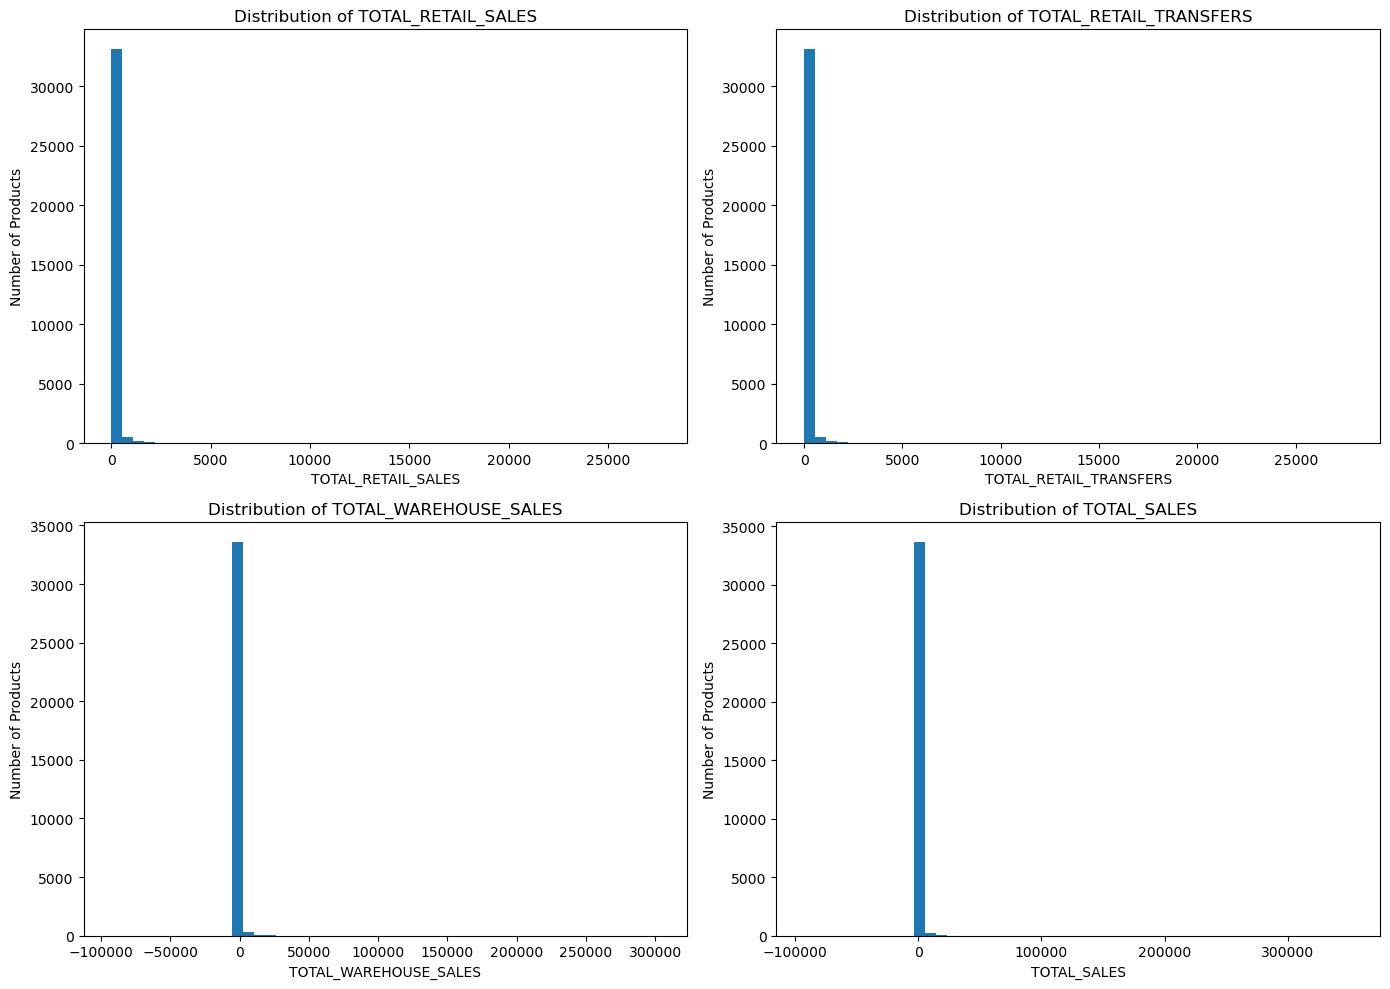

In [9]:
# ============================================
# Step 6: Product-Level Sales Distributions
# ============================================

import matplotlib.pyplot as plt

# Main sales features
distribution_features = [
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'TOTAL_SALES'
]

# Create distribution plots
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for ax, column in zip(axes.flatten(), distribution_features):
    ax.hist(
        product_features[column],
        bins=50
    )
    
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

In [10]:
# ============================================
# Step 7: Reduce Sales Skewness
# ============================================

def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

sales_features = [
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'AVG_RETAIL_SALES',
    'AVG_RETAIL_TRANSFERS',
    'AVG_WAREHOUSE_SALES',
    'STD_RETAIL_SALES',
    'STD_RETAIL_TRANSFERS',
    'STD_WAREHOUSE_SALES',
    'TOTAL_SALES'
]

product_model = product_features.copy()

for col in sales_features:
    product_model[col] = signed_log(product_model[col])

print("Transformation completed.")
print("Shape:", product_model.shape)

display(product_model.head())

Transformation completed.
Shape: (34056, 14)


,ITEM CODE,TOTAL_RETAIL_SALES,TOTAL_RETAIL_TRANSFERS,TOTAL_WAREHOUSE_SALES,AVG_RETAIL_SALES,AVG_RETAIL_TRANSFERS,AVG_WAREHOUSE_SALES,STD_RETAIL_SALES,STD_RETAIL_TRANSFERS,STD_WAREHOUSE_SALES,TOTAL_SALES,ACTIVE_MONTHS,SUPPLIER,ITEM_TYPE
0,100002,0.157004,0.0,0.000000,0.157004,0.0,0.000000,0.000000,0.0,0.000000,0.157004,1,RELIABLE CHURCHILL LLLP,LIQUOR
1,100007,0.000000,0.0,1.609438,0.000000,0.0,0.693147,0.000000,0.0,0.000000,1.609438,4,CONSTANTINE WINES INC,WINE
2,100008,0.000000,0.0,1.386294,0.000000,0.0,0.693147,0.000000,0.0,0.693147,1.386294,3,CONSTANTINE WINES INC,WINE
3,100009,1.000632,0.0,2.944439,0.124258,0.0,0.869038,0.211806,0.0,1.213209,3.031099,13,REPUBLIC NATIONAL DISTRIBUTING CO,WINE
4,100011,0.000000,0.0,1.386294,0.000000,0.0,0.693147,0.000000,0.0,0.000000,1.386294,3,INTERBALT PRODUCTS CORP,WINE


In [11]:
# ============================================
# Step 8: Prepare Features for Clustering
# ============================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numerical features
numerical_features = [
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'AVG_RETAIL_SALES',
    'AVG_RETAIL_TRANSFERS',
    'AVG_WAREHOUSE_SALES',
    'STD_RETAIL_SALES',
    'STD_RETAIL_TRANSFERS',
    'STD_WAREHOUSE_SALES',
    'TOTAL_SALES',
    'ACTIVE_MONTHS'
]

# Categorical feature
categorical_features = ['ITEM_TYPE']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Prepare data
X = product_model[numerical_features + categorical_features]

# Transform features
X_processed = preprocessor.fit_transform(X)

print("Original feature shape:", X.shape)
print("Processed feature shape:", X_processed.shape)

Original feature shape: (34056, 12)
Processed feature shape: (34056, 19)


In [12]:
# ============================================
# Step 9: Find Best Number of Clusters
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test different numbers of clusters
k_values = [2, 3, 4, 5, 6, 7, 8]

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_processed)
    
    score = silhouette_score(
        X_processed,
        labels
    )
    
    silhouette_scores.append(score)
    
    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.5890
K = 3 | Silhouette Score = 0.4089
K = 4 | Silhouette Score = 0.3919
K = 5 | Silhouette Score = 0.3912
K = 6 | Silhouette Score = 0.3719
K = 7 | Silhouette Score = 0.3086
K = 8 | Silhouette Score = 0.3250


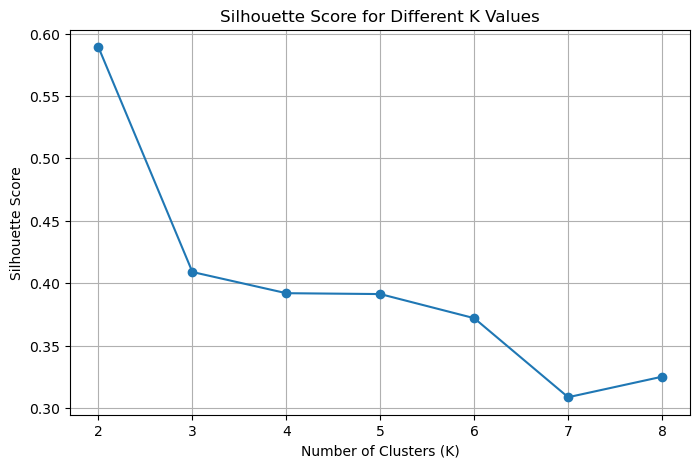

In [13]:
# ============================================
# Step 10: Silhouette Score Comparison
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [14]:
# ============================================
# Step 11: Final K-Means Model
# ============================================

from sklearn.cluster import KMeans

# Train final model
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Create cluster labels
product_model['CLUSTER'] = final_kmeans.fit_predict(X_processed)

# Check cluster sizes
print("Cluster Distribution:")
print(product_model['CLUSTER'].value_counts().sort_index())

Cluster Distribution:
CLUSTER
0    28452
1     5604
Name: count, dtype: int64


In [16]:
# ============================================
# Step 12: Compare the Two Clusters
# ============================================

cluster_summary = product_model.groupby('CLUSTER')[[
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'AVG_RETAIL_SALES',
    'AVG_RETAIL_TRANSFERS',
    'AVG_WAREHOUSE_SALES',
    'TOTAL_SALES',
    'ACTIVE_MONTHS'
]].mean()

print(cluster_summary.round(2).to_string())

         TOTAL_RETAIL_SALES  TOTAL_RETAIL_TRANSFERS  TOTAL_WAREHOUSE_SALES  AVG_RETAIL_SALES  AVG_RETAIL_TRANSFERS  AVG_WAREHOUSE_SALES  TOTAL_SALES  ACTIVE_MONTHS
CLUSTER                                                                                                                                                            
0                      0.48                    0.35                   1.77              0.13                  0.08                 0.91         2.14           6.83
1                      4.85                    4.86                   4.26              2.17                  2.18                 2.01         6.26          20.23


In [17]:
# ============================================
# Step 13: Final Clustering Evaluation
# ============================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(
    X_processed,
    product_model['CLUSTER']
)

davies_bouldin = davies_bouldin_score(
    X_processed,
    product_model['CLUSTER']
)

calinski = calinski_harabasz_score(
    X_processed,
    product_model['CLUSTER']
)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {calinski:.2f}")

Silhouette Score: 0.5890
Davies-Bouldin Index: 0.8166
Calinski-Harabasz Score: 33697.27


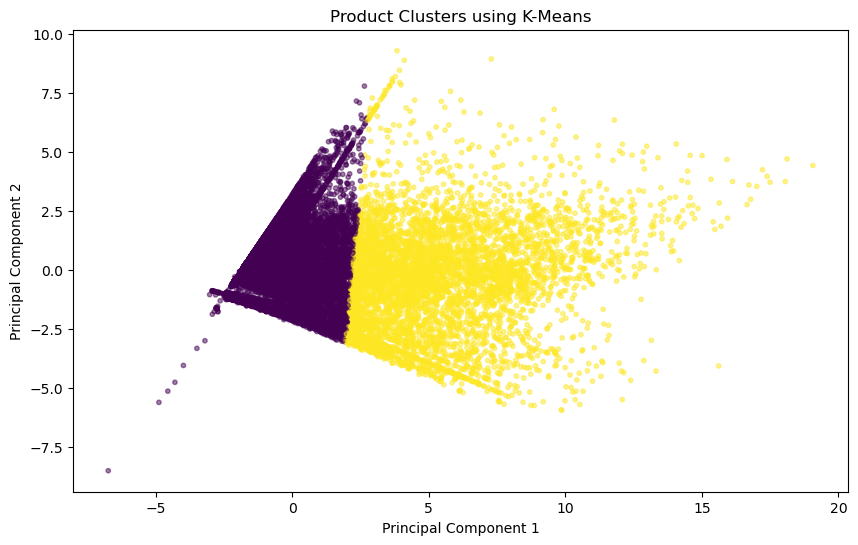

Explained Variance: 85.49 %


In [19]:
# ============================================
# Step 14: Visualize Product Clusters
# ============================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Convert to dense format only if needed
if hasattr(X_processed, "toarray"):
    X_dense = X_processed.toarray()
else:
    X_dense = X_processed

# Reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

# Plot clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=product_model['CLUSTER'],
    s=10,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Product Clusters using K-Means")

plt.show()

print(
    "Explained Variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

In [20]:
# ============================================
# Step 15: Final Cluster Profile
# ============================================

# Add cluster labels to the original product data
final_profile = product_features.copy()
final_profile['CLUSTER'] = product_model['CLUSTER']

# Calculate average original values for each cluster
profile = final_profile.groupby('CLUSTER')[[
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'TOTAL_SALES',
    'ACTIVE_MONTHS'
]].mean()

print("Final Cluster Profile:")
print(profile.round(2).to_string())

# Cluster sizes
print("\nCluster Sizes:")
print(final_profile['CLUSTER'].value_counts().sort_index().to_string())

Final Cluster Profile:
         TOTAL_RETAIL_SALES  TOTAL_RETAIL_TRANSFERS  TOTAL_WAREHOUSE_SALES  TOTAL_SALES  ACTIVE_MONTHS
CLUSTER                                                                                               
0                      2.19                    1.57                  17.73        21.49           6.83
1                    374.46                  372.83                1298.62      2045.90          20.23

Cluster Sizes:
CLUSTER
0    28452
1     5604


In [21]:
# ============================================
# Step 16: Save Final Cluster Results
# ============================================

# Add meaningful cluster names
final_profile['CLUSTER_NAME'] = final_profile['CLUSTER'].map({
    0: 'Low-Activity Products',
    1: 'High-Activity Products'
})

# Save results
final_profile.to_csv(
    'product_cluster_results.csv',
    index=False
)

print("Final clustered dataset saved successfully.")

print("\nCluster Summary:")
print(
    final_profile[
        ['CLUSTER', 'CLUSTER_NAME']
    ].value_counts().sort_index().to_string()
)

Final clustered dataset saved successfully.

Cluster Summary:
CLUSTER  CLUSTER_NAME          
0        Low-Activity Products     28452
1        High-Activity Products     5604


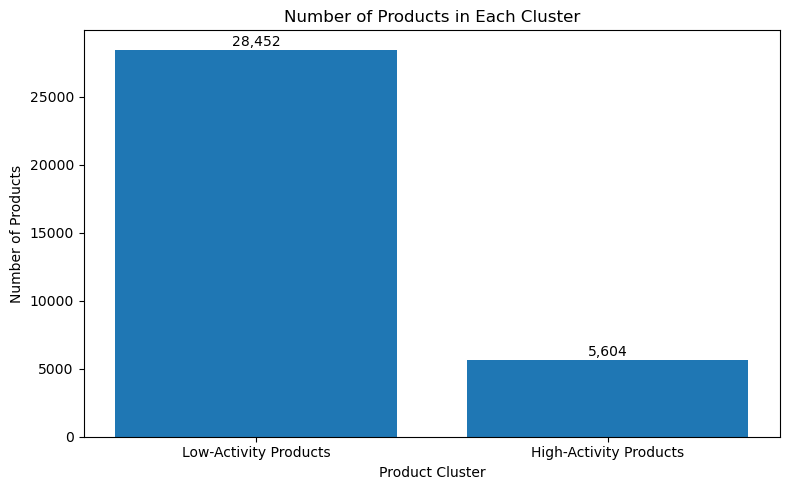

In [22]:
# ============================================
# Step 17: Cluster Size Visualization
# ============================================

import matplotlib.pyplot as plt

cluster_counts = final_profile['CLUSTER_NAME'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index,
    cluster_counts.values
)

plt.title("Number of Products in Each Cluster")
plt.xlabel("Product Cluster")
plt.ylabel("Number of Products")

# Add values on top of bars
for i, value in enumerate(cluster_counts.values):
    plt.text(
        i,
        value + 300,
        f"{value:,}",
        ha='center'
    )

plt.tight_layout()
plt.show()

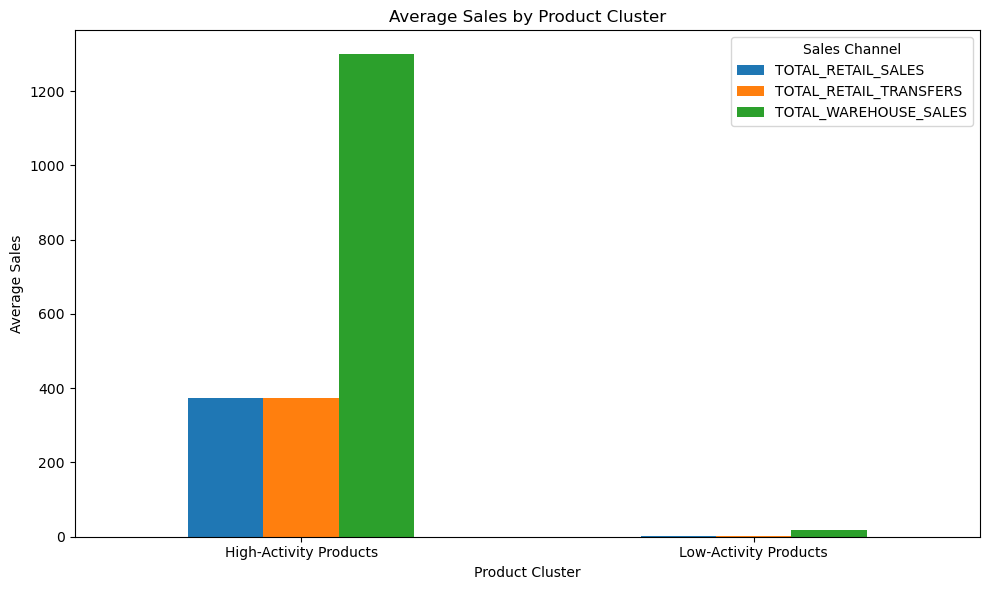

In [23]:
# ============================================
# Step 18: Sales Comparison by Cluster
# ============================================

sales_comparison = final_profile.groupby('CLUSTER_NAME')[
    ['TOTAL_RETAIL_SALES',
     'TOTAL_RETAIL_TRANSFERS',
     'TOTAL_WAREHOUSE_SALES']
].mean()

sales_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Average Sales by Product Cluster")
plt.xlabel("Product Cluster")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.legend(title="Sales Channel")
plt.tight_layout()
plt.show()

In [26]:
# ============================================
# Step 19: Test Model with Real Products
# ============================================

# Select a few real products from our dataset
test_indices = [100, 500, 1000, 5000]

# Get their processed feature values
X_test_real = X_processed[test_indices]

# Predict their clusters
test_predictions = final_kmeans.predict(X_test_real)

# Create a test result table
test_results = product_features.iloc[test_indices][[
    'ITEM CODE',
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'TOTAL_SALES',
    'ACTIVE_MONTHS'
]].copy()

# Add predicted cluster
test_results['PREDICTED_CLUSTER'] = test_predictions

# Add meaningful cluster name
test_results['PREDICTED_CLUSTER_NAME'] = test_results[
    'PREDICTED_CLUSTER'
].map({
    0: 'Low-Activity Products',
    1: 'High-Activity Products'
})

print("Real Product Test Results:")
display(test_results)

Real Product Test Results:


,ITEM CODE,TOTAL_RETAIL_SALES,TOTAL_RETAIL_TRANSFERS,TOTAL_WAREHOUSE_SALES,TOTAL_SALES,ACTIVE_MONTHS,PREDICTED_CLUSTER,PREDICTED_CLUSTER_NAME
100,10127,0.0,0.0,1.0,1.0,1,0,Low-Activity Products
500,10947,0.0,0.0,3.0,3.0,3,0,Low-Activity Products
1000,12008,0.0,0.0,71.0,71.0,15,0,Low-Activity Products
5000,235692,0.5,0.0,0.0,0.5,1,0,Low-Activity Products


In [27]:
# ============================================
# Step 20: Test Low- and High-Activity Products
# ============================================

# Find one real product from each cluster
low_activity_index = product_model[
    product_model['CLUSTER'] == 0
].index[0]

high_activity_index = product_model[
    product_model['CLUSTER'] == 1
].index[0]

# Get their positions
test_indices = [
    low_activity_index,
    high_activity_index
]

# Predict clusters
X_test = X_processed[test_indices]
predictions = final_kmeans.predict(X_test)

# Create test result table
test_results = product_features.iloc[test_indices][[
    'ITEM CODE',
    'TOTAL_RETAIL_SALES',
    'TOTAL_RETAIL_TRANSFERS',
    'TOTAL_WAREHOUSE_SALES',
    'TOTAL_SALES',
    'ACTIVE_MONTHS'
]].copy()

test_results['PREDICTED_CLUSTER'] = predictions

test_results['PREDICTED_CLUSTER_NAME'] = test_results[
    'PREDICTED_CLUSTER'
].map({
    0: 'Low-Activity Products',
    1: 'High-Activity Products'
})

print("Low-Activity vs High-Activity Product Test:")
display(test_results)

Low-Activity vs High-Activity Product Test:


,ITEM CODE,TOTAL_RETAIL_SALES,TOTAL_RETAIL_TRANSFERS,TOTAL_WAREHOUSE_SALES,TOTAL_SALES,ACTIVE_MONTHS,PREDICTED_CLUSTER,PREDICTED_CLUSTER_NAME
0,100002,0.17,0.0,0.0,0.17,1,0,Low-Activity Products
35,10052,53.91,64.0,0.0,117.91,2,1,High-Activity Products


## Model Testing

The trained K-Means model was tested using real products from both identified clusters.

The model successfully assigned:
- A low-activity product to the **Low-Activity Products** cluster.
- A high-activity product to the **High-Activity Products** cluster.

This demonstrates how the trained clustering model can assign new product observations to meaningful product segments based on their sales behavior.